# EDA — Field Asset Health Monitor Project

Stage 2: distributions, investigations, and findings (Q&A).
Consumes the output of `01_preprocessing.ipynb`.

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import pandas as pd
from fahm import preprocessing as pp
from fahm import plotting as pl

cfg = pp.load_config("../configs/config.yaml")

# D10 contract: EDA consumes the ARTIFACT of 01_preprocessing —
# typed, checks-passed parquet. Never re-does preprocessing work.
df = pp.load_processed(cfg)
fw = pd.read_csv(cfg["paths"]["failure_windows"],
                 parse_dates=["start", "end", "maintenance"])
print(df.shape, "| failures:", len(fw))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(1516948, 16) | failures: 4


#### Lets a have a look on autoviz eda, knowing that a manual eda is a must for this kind of data

In [3]:
pdf_path = "../docs/autoviz_report.pdf"

# Check if the PDF report is already generated
if os.path.exists(pdf_path):
    print(f"Skipping report generation: '{pdf_path}' already exists.")
else:
    print("Generating one-time skim report in docs/...")
    pl.auto_eda_pdf(df, pdf_path)

Skipping report generation: '../docs/autoviz_report.pdf' already exists.


In [4]:
from IPython.display import HTML

HTML('<a href=pdf_path target="_blank">📄 Click here to view the full report (PDF)</a>')

#### making manual EDA

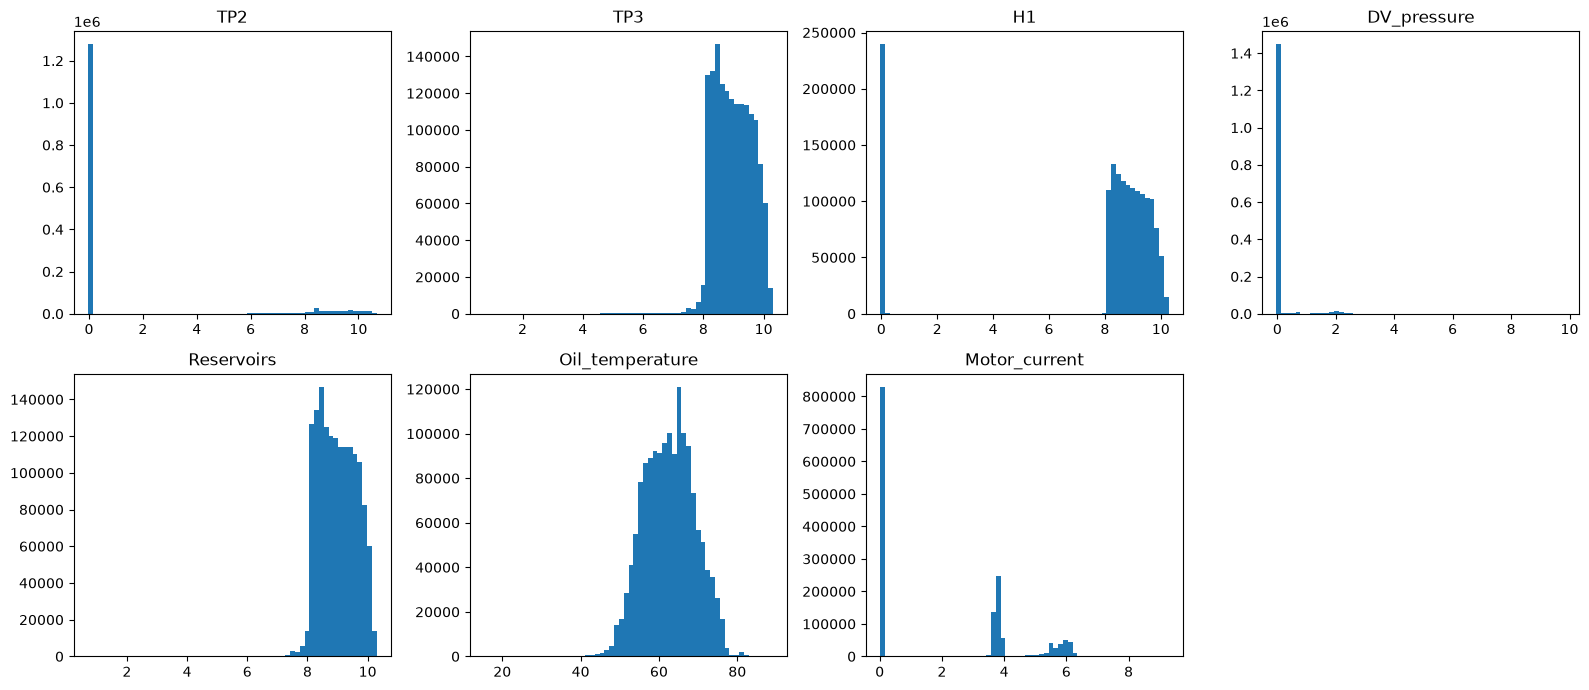

In [5]:
fig_ad = pl.plot_analog_distributions(df)

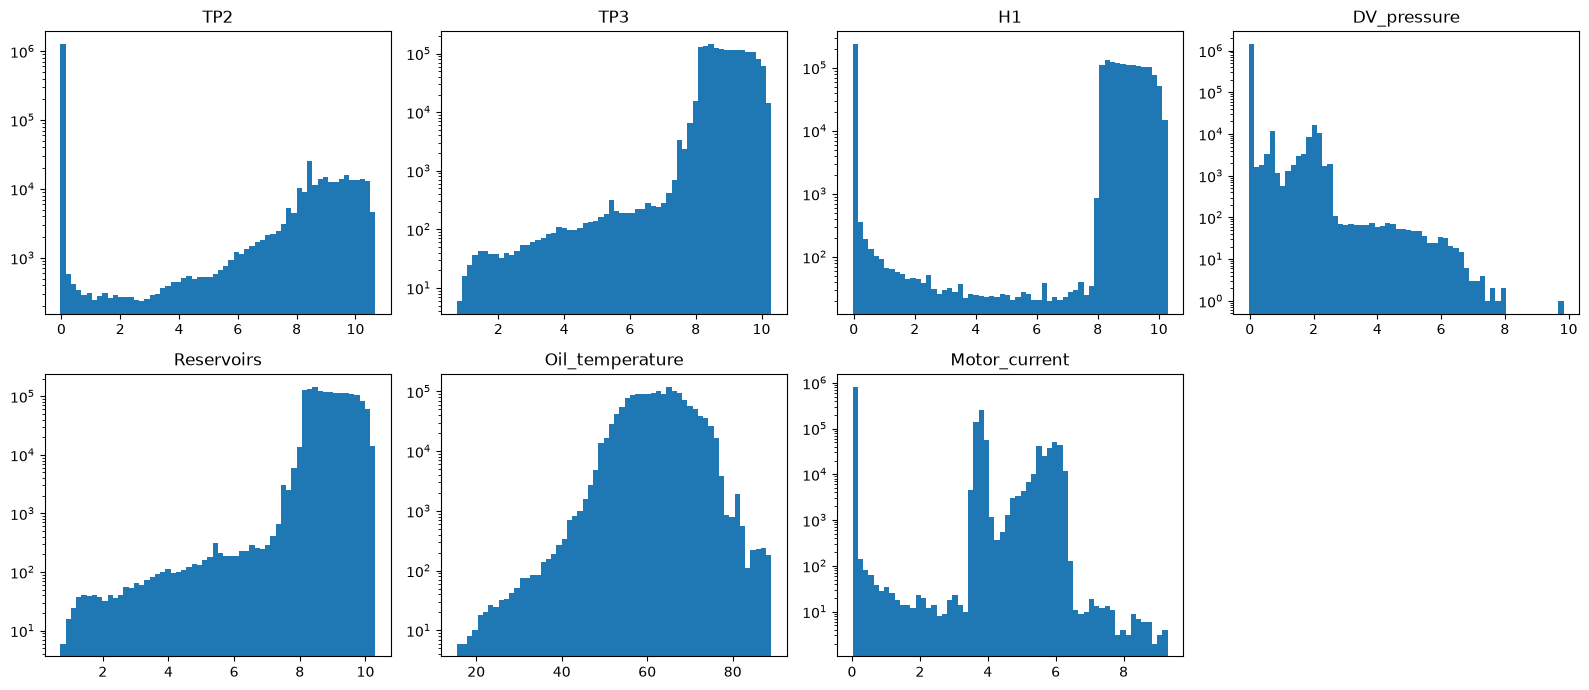

In [6]:
fig_adl = pl.plot_analog_distributions(df, log=True)

In [7]:
summary = pl.digital_summary(df)
summary

,n_zeros,n_ones,n_other,frac_active
signal,,,,
COMP,247328,1269620,0,0.8370
DV_eletric,1273310,243638,0,0.1606
Towers,121586,1395362,0,0.9198
MPG,253840,1263108,0,0.8327
LPS,1511760,5188,0,0.0034
Pressure_switch,12990,1503958,0,0.9914
Oil_level,145391,1371557,0,0.9042
Caudal_impulses,95406,1421542,0,0.9371


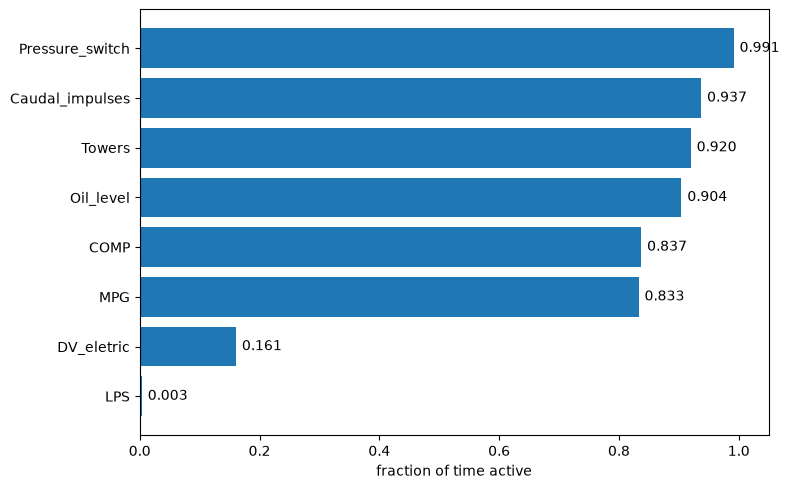

In [8]:
fig_ds = pl.plot_digital_summary(summary)

#### saving plots

In [9]:
pl.save_fig(fig_ad, "analog_distributions", cfg)
pl.save_fig(fig_adl, "analog_distributions_log", cfg)
pl.save_fig(fig_ds, "digital_frac_active", cfg)

PosixPath('/home/leoadmin/Documents/GitHub/FAHM_Project/docs/figures/digital_frac_active.png')

#### Some investigations to have a better insight

## EDA Findings: Questions & Answers

---

### Q1 — Which analog sensors are multi-modal, and why (physically)?

**TP2, H1, Motor_current, and DV_pressure.**

**Rule of thumb: N modes ⇔ N relevant machine states for that sensor!**

Which means that each sensor has as many peaks as it has distinct machine states,
the modes map to the machine's operating stated:

- **TP2 and H1** — 2 modes: ~0 bar at idle vs. 8–10 bar under load.
- **Motor_current** — 3 modes, **~0 A = motor off.**
  **~4 A = offloaded running** (motor spinning, intake closed, no compression — TP2 = 0, COMP = 1)
  as we know from the paper, there is a cross-referencing between TP2 and COMP in time.
  **~5.5–6.2 A = under load** (compressing — TP2 sawtooth 8–10 bar, COMP = 0).
  
  note: the large 3.9 A histogram mode (on 6.4 after 16:15) is large because OFFLOADED running lasts
  minutes and not loading, which can be confusing.*
- **DV_pressure** — 2 modes: ~0 while the compressor works under load vs.
  1–2 bar during tower-discharge events.



In [10]:
# 1. locate the extreme value
idx = df["DV_pressure"].idxmax()
df.loc[idx - 3 : idx + 3]          # the row + 3 neighbors each side (10s apart)

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
481274,2020-04-06 14:18:00,9.820,9.678,-0.014,1.244,9.678,71.450,5.9625,0,1,0,0,0,1,1,1
481275,2020-04-06 14:18:09,9.824,9.682,-0.012,4.328,9.680,71.275,6.0300,0,1,0,0,0,1,1,1
481276,2020-04-06 14:18:19,8.558,9.696,-0.014,3.616,9.694,71.350,5.6800,0,1,1,0,0,1,1,1
481277,2020-04-06 14:18:29,10.100,9.798,-0.014,9.844,9.796,71.375,6.0700,0,1,1,0,0,1,1,1
481278,2020-04-06 14:18:39,10.258,9.970,-0.014,3.330,9.966,71.525,6.0725,0,1,1,0,0,1,1,1
481279,2020-04-06 14:18:49,10.406,10.122,-0.014,2.316,10.120,71.450,6.2775,0,1,1,0,0,1,1,1
481280,2020-04-06 14:18:59,9.672,10.172,-0.012,0.004,10.168,71.425,6.1000,0,1,1,0,0,1,1,1


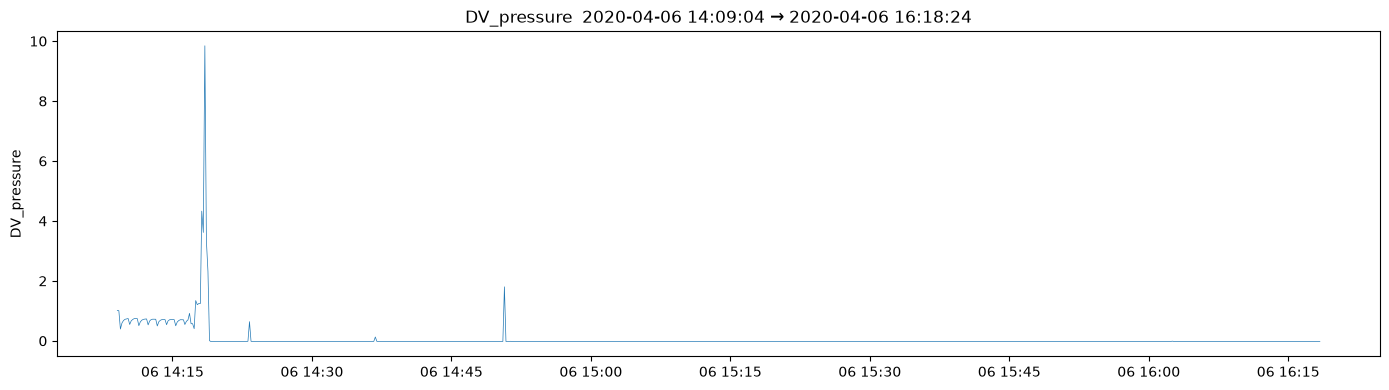

In [11]:
# 2. see its neighborhood in time
t = df.loc[idx, "timestamp"]
fig_s_tl = pl.plot_sensor_timeline(df, "DV_pressure",t - pd.Timedelta("2h"), t + pd.Timedelta("2h"))

In [12]:
pl.save_fig(fig_s_tl, "DV_pressure_isolate_peak", cfg)

PosixPath('/home/leoadmin/Documents/GitHub/FAHM_Project/docs/figures/DV_pressure_isolate_peak.png')

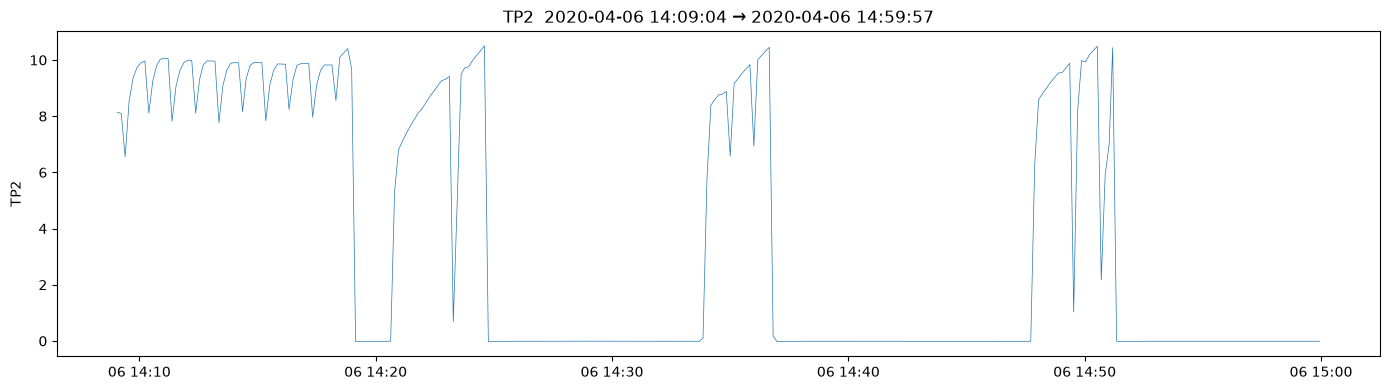

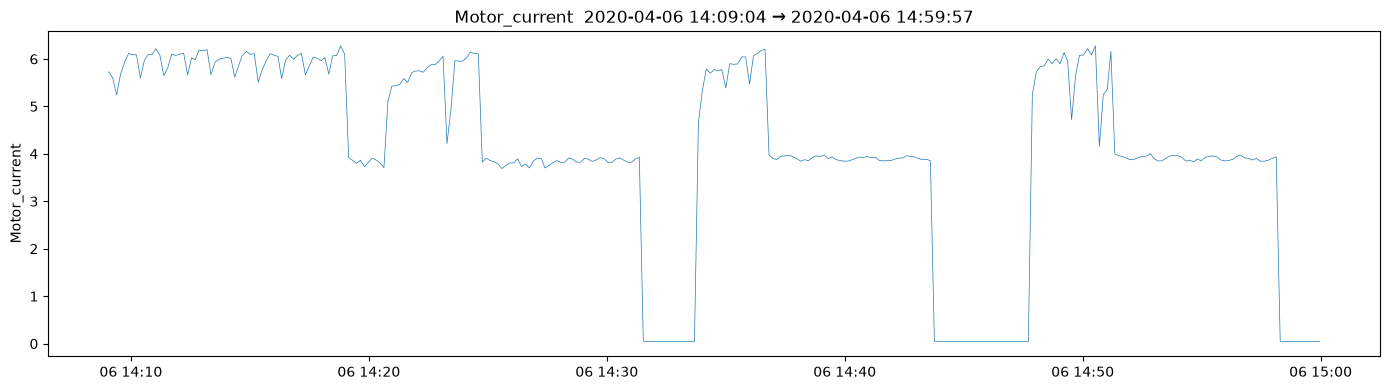

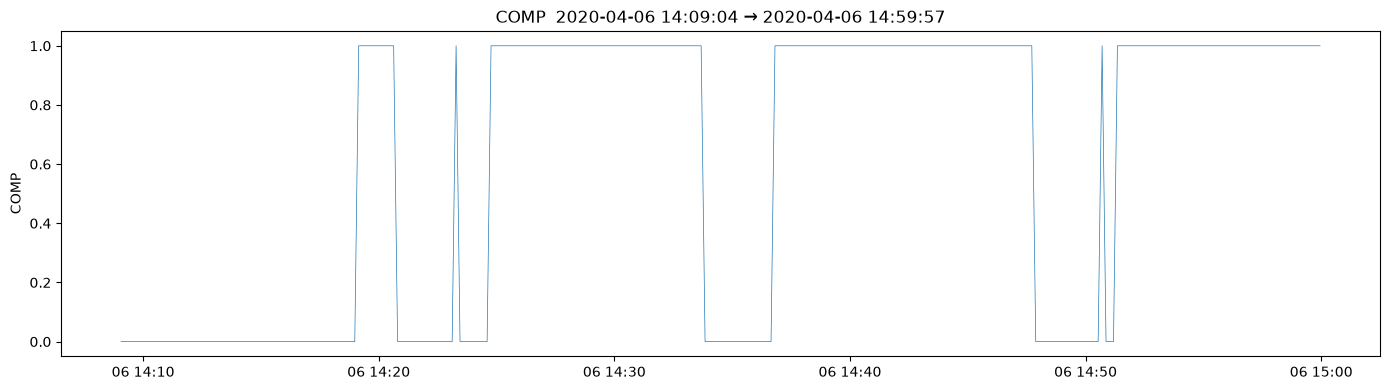

In [13]:
for s in ["TP2", "Motor_current", "COMP"]: fig = pl.plot_sensor_timeline(df, s, "2020-04-06 14:00", "2020-04-06 15:00")

**Investigated via multi-sensor timeline (DV_pressure, TP2, Motor_current, COMP):** 
real operational episode, not a glitch.

Ten minutes of abnormally rapid loaded cycling (~1 cycle/min, motor ~6A, COMP=0) beginning right after a ~1h50m recording gap,
terminating in the 9.8 bar discharge spike at 14:18, followed by offloaded running (TP2=0, COMP=1, motor ~3.9A) with brief load bursts.

Consistent with a maintenance/test session. Side finding: 
corrected the Motor_current mode mapping — ~3.9A = offloaded running (not sustained load), ~6A = under load — matching the paper's documented levels.

### Q2 — Which sensor pair has near-identical distributions?

**There is a similar distribution between the sensors TP3 and Reservoirs.**  They measure the same connected air volume at two
different points, as we know from the paper notes - visible in the correlation heatmap and in the raw values (identical to 3
decimals in head()).

→ consistency check mean(|TP3 − Reservoirs|) < ε.

In [14]:
display((df["TP3"] - df["Reservoirs"]).abs().describe())

count    1.516948e+06
mean     1.862102e-03
std      1.712118e-03
min      0.000000e+00
25%      0.000000e+00
50%      2.000000e-03
75%      2.000000e-03
max      1.820000e-01
dtype: float64

**Quantified: mean |TP3 − Reservoirs| = 0.0019 bar** 
- median 0.002, max 0.182 over 7 months; differences quantized in 0.002 bar steps — the sensors' resolution.
- The max is consistent with fast-pressure transients sampled 10s apart at two circuit points. 
- **conclusion: → ε = 0.02 bar** set in config (≈5× observed mean): trips on real divergence, passes all observed normal operation.

---

### Q3 — Digital signals: does n_other == 0 for all eight? 
### And do any fracion active values surprise you given the sensor's documented meaning? 

**Purity: `n_other == 0` for all eight signals on the full 1,516,948 rows** —
every digital column contains only {0, 1}. This is the full-data proof that
the int8 cast in D04 was safe (and the real version of what AutoViz could
only confirm on a sample).

**Surprising fractions:**

- **Oil_level = 0.904 active**, yet the docs say active = "oil below
  expected level". A machine running with an oil fault for ~90% of seven
  months is implausible → working hypothesis: **polarity inverted in this
  data release** (active = OK; the interesting 10% is the *inactive* time).
  **Test (redesigned after source check, see D07):** all four documented
  failures are air leaks — there is no oil-leak window to test against.
  Instead: locate *when* the ~10% inactive time occurs
  (`df.loc[df["Oil_level"] == 0, "timestamp"]`) and check whether it
  clusters around failures, maintenance dates, or recording gaps
  (→ polarity/behavior hypothesis) or scatters randomly (→ something else).
- **Pressure_switch = 0.991 active** — documented as detecting tower
  discharge *events*, which are brief; an event detector active 99% of the
  time suggests the same inverted/level-type behavior. Same clustering
  test applies to its 1% inactive time.

In [15]:
s = df["COMP"] + df["DV_eletric"]
display(print(f"the s mean is: {s.mean()}, the sum 's!=1' is: {(s != 1).sum()}"))
print(f"s value counts:\n{s.value_counts()}")

the s mean is: 0.9975674841853511, the sum 's!=1' is: 16762


None

s value counts:
1    1500186
0      10226
2       6536
Name: count, dtype: int64


**Bonus finding — valve antiphase, quantified:** COMP (0.837) +
DV_eletric (0.161) sum to ≈ 1, and on the full data:
**mean(COMP + DV_eletric) = 0.9976**, with the sum equal to exactly 1 in
**98.9%** of samples. The 16,762 violations (10,226 both-inactive, 6,536
both-active) match the expected order of magnitude of load/unload
*transitions* caught mid-switch by 10-second decimated snapshots — boundary
sampling, not a real third state. (The asymmetry fits too: the switching
sequence passes through "both closed" more often than "both open".)

→ **Check `|mean(COMP + DV_eletric) − 1| < 0.02`**
(`valve_antiphase_eps` in config; observed deviation 0.0024 → ~8× headroom).

---

### Q4 — Data errors vs. machine behavior

- **TP2 idle mode ≈ −0.012 bar** — negative pressure is physically
  impossible, so this is sensor **zero-offset (calibration)**, not an
  error. Consequence: analog range checks must tolerate small negative
  pressures, or they will false-alarm on normal idle.

- **DV_pressure: single ~9.8 bar sample in 1.5M rows** — investigated via
  multi-sensor timeline (DV_pressure, TP2, Motor_current, COMP on
  2020-04-06): **real operational episode, not a glitch.**
  The full story: a ~1h50m recording gap ends at 14:09 (revealed by the
  plot window truncating itself); then ten minutes of abnormally rapid
  loaded cycling (~1 cycle/min, motor ~6 A, COMP = 0) — unusually intense,
  high-demand operation; terminating in the 9.8 bar discharge spike at
  ~14:18; followed by offloaded running (TP2 = 0, COMP = 1, motor ~3.9 A)
  with brief load bursts every ~10 min. Consistent with a
  **maintenance/test session** (e.g., brake tests + vent + standby).
  Dated 12 days before failure F1 — probably unrelated to it.
  Classified as rare *behavior*, not data error.

- **Motor_current tail > 8 A** (counts < 10): rare start-up transients —
  plausible behavior.

- **TP3 / Reservoirs thin low tail down to ~0.7 bar**: rare deep
  depressurizations — likely post-failure moments; to be cross-checked
  against the failure windows in step 5.

---
## Sensor relationships (correlation)
Autoviz's heatmap surfaced the TP3–Reservoirs pair; here is the project-owned
version on the full data (autoviz sampled).

In [26]:
corr = df[pp.ANALOG].corr()
corr.round(3)

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current
TP2,1.000,-0.011,-0.961,0.415,-0.012,0.251,0.697
TP3,-0.011,1.000,0.225,-0.153,1.000,0.402,0.414
H1,-0.961,0.225,1.000,-0.426,0.226,-0.162,-0.600
DV_pressure,0.415,-0.153,-0.426,1.000,-0.153,0.340,0.302
Reservoirs,-0.012,1.000,0.226,-0.153,1.000,0.402,0.413
Oil_temperature,0.251,0.402,-0.162,0.340,0.402,1.000,0.529
Motor_current,0.697,0.414,-0.600,0.302,0.413,0.529,1.000


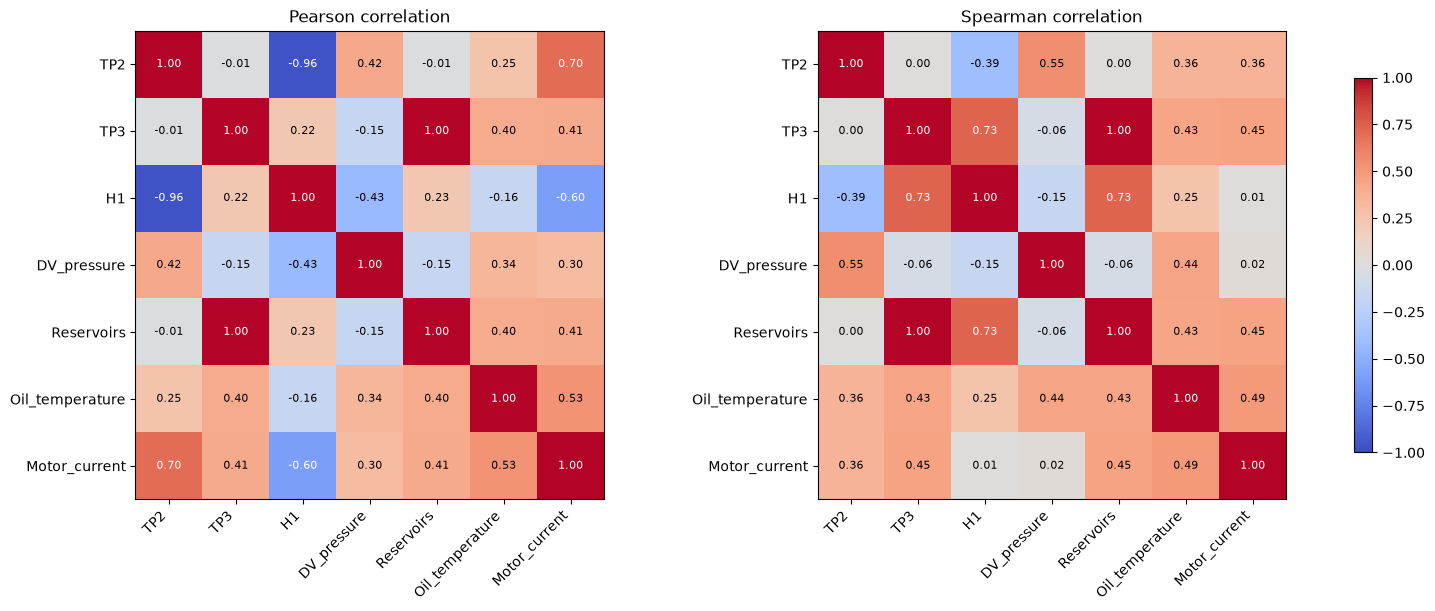

In [23]:
fig_corr = pl.plot_correlation_heatmaps(df)

In [24]:
pl.save_fig(fig_corr, "analog_correlation_heatmaps", cfg)

PosixPath('/home/leoadmin/Documents/GitHub/FAHM_Project/docs/figures/analog_correlation_heatmaps.png')

#### **Reading the correlation heatmaps (state lens, D12):**

- TP3–Reservoirs = 1.00 in both — the twin pair, third independent confirmation.
- TP2–H1: Pearson −0.96 vs Spearman −0.39. H1 is antiphase to TP2 (H1 ≈ TP3 while idle, ≈ 0 under load — visible in head() and the Apr 6 rows). Pearson's −0.96 is the      two-state jump dressed as a linear law: both sensors leap between their modes in opposite directions, and the extremes dominate. Spearman, ranking within modes too, is diluted by within-mode noise.
- H1–TP3: the mirror-image disagreement — Spearman 0.73 vs Pearson 0.22. During idle, H1 tracks TP3 almost exactly (strong rank relation); under load H1 sits at ~0 while TP3 stays high, and those samples wreck the linear fit. Same state mixture, opposite effect on the two measures.
- TP2–Motor_current: Pearson 0.70 vs Spearman 0.36 — co-occurrence of the load state drives the linear number; ranks within idle (current ≈ 0.04 A noise) carry no order.
- Oil_temperature: lukewarm (~0.4–0.5) with everything — it follows workload with lag, which same-timestamp correlation can't see (D12's known limitation).

**Conclusion:** every large Pearson–Spearman disagreement here is the machine's state structure, not skew — the textbook recipe would have prescribed log transforms for what is actually mode mixture. Correlation on raw sensors describes which sensors share a state; redundancy/feature conclusions wait for engineered features.

---
## Findings feed-forward
What this notebook hands to the next stages:

- **To 03 (anomaly context):** OQ1 — Oil_level / Pressure_switch inactive-time
  clustering vs failures/maintenance/gaps; OQ2 — post-gap behavior (the Apr 6
  episode began 9 min after a gap). Both now testable: `fw` (failure windows)
  and `pp.find_gaps(df, cfg)` are available.
- **To 04 (features):** loaded-state definition keys on COMP/DV_eletric
  (Motor_current corroborates only — D06); TP3 idle-decay slope is the most
  direct leak signal; duty fraction is the machine's vital sign; post-gap
  minutes may need a warm-up rule (pending OQ2).
- **Known limits:** 10 s decimated grid — sub-20 s events and spectral
  features are out of scope by data availability.